# Tutorial 02: NVT cavity MD with a single A–A dimer

In this tutorial, we will be simulating the same single-dimer + photon system as Tutorial 01, but now in the canonical (NVT) ensemble.

We attach a Bussi–Parrinello CSVR thermostat to the molecular atoms only. The cavity-mode particle (index 2) is excluded from the bath and thermalizes through mechanical coupling to the dipole.

What we will do is as follows:

1. Import the OpenMM cavity-MD extensions and mKA force-field constants
2. Set up the OpenMM `System`, integrator, thermostat, and initial conditions
3. Run a short MD trajectory and record the molecular dipole $\mathbf{d}(t)$ (and $T_\text{kin}$)
4. Post-process an IR-style spectrum from that dipole time series

**Kernel:** register / select the pixi `test` environment kernel before running cells (see Tutorial 01).

### Unit conventions

The mKA parameters are defined in atomic units (Hartree / Bohr / electron mass).
OpenMM stores energies, lengths, and times in kJ/mol, nm, and ps (please be aware of this!). The `Units` helper from `openmm.cavitymd.constants` performs the conversions used below.


## 1. Import the codebase


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import openmm
from openmm import unit

from openmm.cavitymd.constants import Units
from openmm.cavitymd.forcefields.mka import (
    MASS_A, MASS_B, PHOTON_MASS_AMU,
    K_AA_AU, R0_AA_AU, K_BB_AU, R0_BB_AU,
    EPS_AA_AU, SIG_AA_AU, EPS_AB_AU, SIG_AB_AU, EPS_BB_AU, SIG_BB_AU,
    CHARGE_MAG, OMEGA_C_CM1,
)
from openmm.cavitymd.thermostats import DualThermostat


# Use this command for sanity check. Does my system support the platforms I am targeting?
print("OpenMM version:", openmm.__version__)
for i in range(openmm.Platform.getNumPlatforms()):
    print(" platform:", openmm.Platform.getPlatform(i).getName())


OpenMM version: 8.5
 platform: Reference
 platform: CPU
 platform: CUDA


Next, we need to define helper functions. One is for computing the dipole magnitude for a single molecule. Finite-$q$ displacement is handled by `CavityParticleDisplacer` (see theory below).


In [2]:
def dipole_magnitude(pos, charges, indices):
    """Translation/rotation-invariant dipole magnitude (|Σ qᵢ rᵢ|)."""
    d = np.dot(charges, pos[indices])
    return np.linalg.norm(d)

AMU_TO_AU_CAVITY = 1822.888486209  # matches CavityForce's internal amu->a.u. mass conversion


## 2. Set simulation parameters

Simulation parameters follow atomic units for the most part, with time following femtosecond unit being the only exception. However, keep in mind that OpenMM operates on different set of units internally. See Section 18.2 in [OpenMM introduction](https://docs.openmm.org/latest/userguide/theory/01_introduction.html)


In [3]:
# ============================================================
# Tunable parameters: change these to explore the physics
# ============================================================
lambda_coupling = 0.5    # cavity coupling λ (a.u.): try 0.0, 0.5, 5.0
T_K             = 100.0   # target temperature (K)
dt_fs           = 1.0     # timestep (fs)
N_steps         = 12_000  # production steps (~12 ps at 1 fs/step)
seed            = 42

# Derived constants
dt_ps     = dt_fs * 1e-3
omegac_au = Units.cm1_to_au(OMEGA_C_CM1)
B2NM      = Units.BOHR_TO_NM
H2K       = Units.HARTREE_TO_KJMOL
k_aa_omm  = K_AA_AU * H2K / B2NM**2
r0_aa_omm = R0_AA_AU * B2NM
half_r0   = r0_aa_omm / 2.0
charges_single = np.array([-CHARGE_MAG, +CHARGE_MAG])

print(f"λ = {lambda_coupling},  T = {T_K} K,  dt = {dt_fs} fs,  ω_c = {OMEGA_C_CM1} cm⁻¹")
print(f"ω_c in a.u. = {omegac_au:.6e} Hartree")
print(charges_single)


λ = 0.5,  T = 100.0 K,  dt = 1.0 fs,  ω_c = 1560.0 cm⁻¹
ω_c in a.u. = 7.107883e-03 Hartree
[-0.3  0.3]


---
## 3. Theory: NVT vs NVE

### Canonical sampling

In NVT the kinetic energy fluctuates around $\tfrac{3}{2} N_\text{mol} k_B T$. The Bussi thermostat rescales molecular velocities each step so the kinetic-energy distribution matches the canonical ensemble (Bussi et al., *J. Chem. Phys.* **126**, 014101, 2007).

### Which atoms feel the bath?

We thermostat particles `[0, 1]` (the dimer) but not the photon (index 2). Usualy, the cavity mode is attached to another bath, assuming it is in contact to an open electromagnetic/radiation environment/field (not sure the proper term is). For now, we assume the cavity mode is perfectly isolated in a high-Q cavity. 

### Same cavity physics as Tutorial 01

At $\lambda \neq 0$ the cavity mode can be shifted to its local, instantaneous equilibrium before dynamics:

$$q_\text{eq} = -\frac{\lambda}{\omega_c} \, d_{xy}$$

`CavityParticleDisplacer` with `setSwitchOnStep(0)` and `setSwitchOnLambda(λ)` performs this finite-$q$ shift on the first integrator step (pass `PHOTON_MASS_AMU` into both `CavityForce` and the displacer — it must match `System.addParticle`). Bond and cavity forces match Tutorial 01; only the thermostat differs.


## 4. Build the OpenMM system

| OpenMM object | Role |
|---|---|
| `HarmonicBondForce` | intramolecular A–A bond |
| `CavityForce` | photon well + bilinear coupling |
| `CavityParticleDisplacer` | finite-$q$ shift at $t=0$ |
| `BussiThermostat` (via `DualThermostat`) | canonical bath on molecular atoms only |
| `VerletIntegrator` | symplectic integrator |

Normally, you would build the system through an external PDB file and other Python packages. Here we keep the OpenMM objects explicit, as in Tutorial 01.


In [13]:
system = openmm.System()
system.addParticle(MASS_A)           # 0: A−
system.addParticle(MASS_A)           # 1: A+
system.addParticle(PHOTON_MASS_AMU)  # 2: photon

bond_force = openmm.HarmonicBondForce()
bond_force.addBond(0, 1, r0_aa_omm, k_aa_omm)
system.addForce(bond_force)

# CavityForce reads charges from NonbondedForce
nb = openmm.NonbondedForce()
nb.setNonbondedMethod(openmm.NonbondedForce.NoCutoff)
nb.addParticle(-CHARGE_MAG, 0.1, 0.0)
nb.addParticle(+CHARGE_MAG, 0.1, 0.0)
nb.addParticle(0.0, 0.1, 0.0)
nb.addException(0, 1, 0.0, 1.0, 0.0)
system.addForce(nb)

# CavityForce includes harmonic well, bilinear coupling, and dipole self-energy by default.
# Pass PHOTON_MASS_AMU — the default photonMass=1.0 amu does NOT match System.addParticle.
cavity_force = openmm.CavityForce(2, omegac_au, lambda_coupling, PHOTON_MASS_AMU)
system.addForce(cavity_force)

displacer = openmm.CavityParticleDisplacer(2, omegac_au, PHOTON_MASS_AMU)
displacer.setSwitchOnStep(0)
displacer.setSwitchOnLambda(lambda_coupling)
system.addForce(displacer)

#A bit unique to our setup. DualThermostat is a clas to define separate thermostats for the system. 
DualThermostat.setup_bussi_for_system(
    system,
    molecular_indices=[0, 1],
    temperature_K=T_K,
    tau_ps=0.0001, #change this to larger values or smaler values. Larger -> weaker coupling. 
    random_number_seed=seed,
)

integrator = openmm.VerletIntegrator(dt_ps)
platform = openmm.Platform.getPlatformByName("CUDA")
platform.setPropertyDefaultValue("Precision", "mixed")
context = openmm.Context(system, integrator, platform)

positions = [
    openmm.Vec3(-half_r0, 0, 0) * unit.nanometer,
    openmm.Vec3(+half_r0, 0, 0) * unit.nanometer,
    openmm.Vec3(0, 0, 0) * unit.nanometer,
]
context.setPositions(positions)
context.setVelocitiesToTemperature(T_K, seed)

pos_nm = context.getState(getPositions=True).getPositions(asNumpy=True).value_in_unit(unit.nanometer)
print(f"System: {system.getNumParticles()} particles, {system.getNumForces()} forces")
print(f"Forces: {[type(system.getForce(i)).__name__ for i in range(system.getNumForces())]}")
print(f"Photon position before finite-q shift: ({pos_nm[2,0]:.4f}, {pos_nm[2,1]:.4f}, {pos_nm[2,2]:.4f}) nm")
# Trigger a first integrator step so CavityParticleDisplacer fires at step 0
integrator.step(1)
pos_nm = context.getState(getPositions=True).getPositions(asNumpy=True).value_in_unit(unit.nanometer)
print(f"Photon position after finite-q shift: ({pos_nm[2,0]:.4f}, {pos_nm[2,1]:.4f}, {pos_nm[2,2]:.4f}) nm")


System: 3 particles, 5 forces
Forces: ['HarmonicBondForce', 'NonbondedForce', 'CavityForce', 'CavityParticleDisplacer', 'BussiThermostat']
Photon position before finite-q shift: (0.0000, 0.0000, 0.0000) nm
Photon position after finite-q shift: (-2.6087, 0.0271, -0.0368) nm


## 5. Run the simulation

We track both the dipole and a running kinetic temperature to confirm the bath is working. At 12,000 steps and 1 fs per step, a GPU run is typically quick.


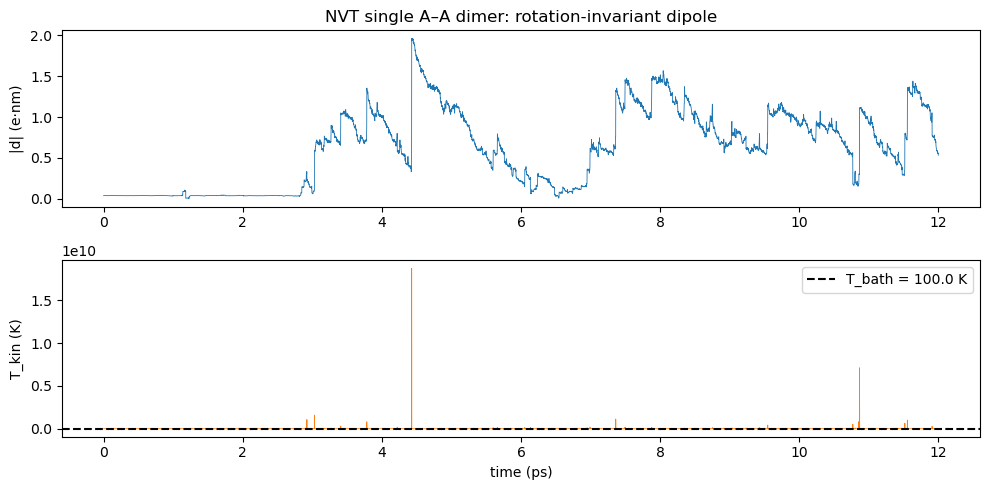

Mean T_kin = 3482428.6 K  (target 100.0 K)


In [14]:
kB_kJ = Units.KB_KJMOL_PER_K
mol_indices = [0, 1]
# BussiThermostat uses setSubtractCMMotion(True) → DOF = 3N−3
dof = 3 * len(mol_indices) - 3
dipoles = []
T_kin = []

for _ in range(N_steps):
    integrator.step(1)
    state = context.getState(getPositions=True, getVelocities=True)
    pos = state.getPositions(asNumpy=True).value_in_unit(unit.nanometer)
    vel = state.getVelocities(asNumpy=True).value_in_unit(unit.nanometer / unit.picosecond)
    dipoles.append(dipole_magnitude(pos, charges_single, mol_indices))
    # Molecular-only KE (exclude ultralight photon); OpenMM: ½ m[amu] v[nm/ps]² → kJ/mol
    ke_mol = 0.0
    for i in mol_indices:
        m = system.getParticleMass(i).value_in_unit(unit.dalton)
        ke_mol += 0.5 * m * float(np.dot(vel[i], vel[i]))
    T_kin.append(2.0 * ke_mol / (dof * kB_kJ))

dipoles = np.array(dipoles)
T_kin = np.array(T_kin)
t_ps = np.arange(N_steps) * dt_ps

fig, axes = plt.subplots(2, 1, figsize=(10, 5))
axes[0].plot(t_ps, dipoles, lw=0.6)
axes[0].set_ylabel("|d| (e·nm)")
axes[0].set_title("NVT single A–A dimer: rotation-invariant dipole")
axes[1].plot(t_ps, T_kin, lw=0.6, color="C1")
axes[1].axhline(T_K, color="k", ls="--", label=f"T_bath = {T_K} K")
axes[1].set_xlabel("time (ps)")
axes[1].set_ylabel("T_kin (K)")
axes[1].legend()
plt.tight_layout()
plt.show()

print(f"Mean T_kin = {T_kin.mean():.1f} K  (target {T_K} K)")


Signal: 12000 points, duration = 12.00 ps


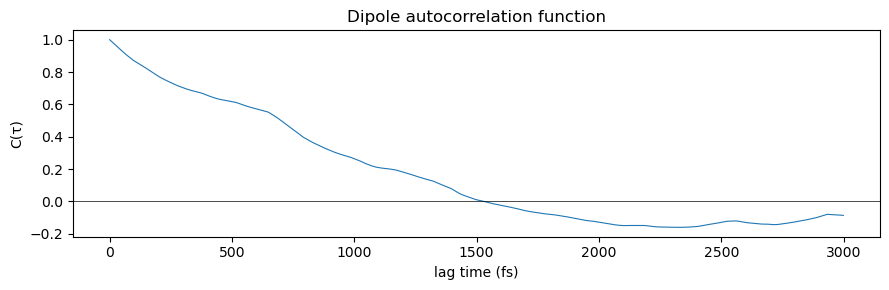

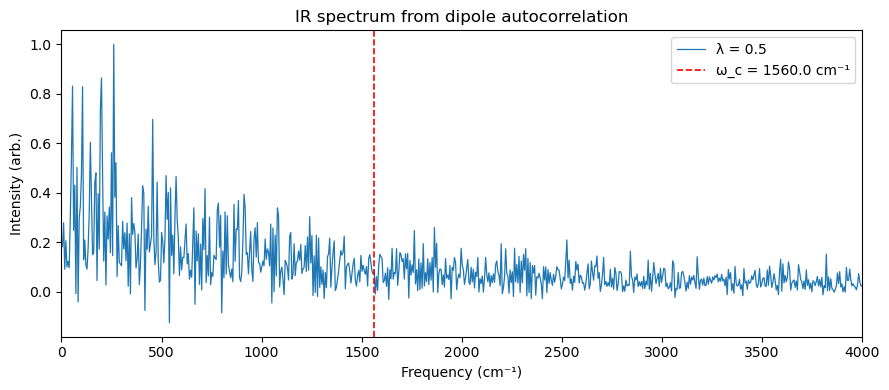

Peak frequency: 523 cm⁻¹   (reference ω_c = 1560 cm⁻¹)


In [15]:
from scipy import fftpack, signal

fraction_acf = 0.25   # use first 25% of ACF (increase trajectory for tighter stats)
dipole_signal = dipoles.copy() - dipoles.mean()
N_sig = len(dipole_signal)
n_acf = max(3, int(N_sig * fraction_acf))
print(f"Signal: {N_sig} points, duration = {N_sig * dt_fs * 1e-3:.2f} ps")

# Unbiased autocorrelation (fftconvolve method)
if N_sig % 2 == 0:
    shifted = np.zeros(2 * N_sig)
else:
    shifted = np.zeros(2 * N_sig - 1)
shifted[N_sig // 2 : N_sig // 2 + N_sig] = dipole_signal
acf_full = signal.fftconvolve(shifted, dipole_signal[::-1], mode="same")[-N_sig:] / np.arange(N_sig, 0, -1)
autocorr = acf_full[:n_acf]

lag_fs = np.arange(n_acf) * dt_fs
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(lag_fs, autocorr / autocorr[0], lw=0.8)
ax.axhline(0, color="k", lw=0.5)
ax.set_xlabel("lag time (fs)")
ax.set_ylabel("C(τ)")
ax.set_title("Dipole autocorrelation function")
plt.tight_layout()
plt.show()

# IR spectrum via DCT (linear response + quantum correction factor)
timestep = dt_fs * 1e-15
lineshape = fftpack.dct(autocorr, type=1)[1:]
freqs_hz = np.linspace(0, 0.5 / timestep, len(autocorr))[1:]
freqs_cm1 = freqs_hz / (100.0 * 299792458.0)

boltz = 1.38064852e-23
hbar = 1.05457180013e-34
field = freqs_hz * (1.0 - np.exp(-hbar * freqs_hz / (boltz * T_K)))
spectrum = lineshape * field

fig, ax = plt.subplots(figsize=(9, 4))
mask = (freqs_cm1 > 0) & (freqs_cm1 <= 4000)
if spectrum[mask].max() > 0:
    ax.plot(freqs_cm1[mask], spectrum[mask] / spectrum[mask].max(), lw=0.9, label=f"λ = {lambda_coupling}")
ax.axvline(OMEGA_C_CM1, color="r", ls="--", lw=1.2, label=f"ω_c = {OMEGA_C_CM1} cm⁻¹")
ax.set_xlim(0, 4000)
ax.set_xlabel("Frequency (cm⁻¹)")
ax.set_ylabel("Intensity (arb.)")
ax.set_title("IR spectrum from dipole autocorrelation")
ax.legend()
plt.tight_layout()
plt.show()

peak_mask = (freqs_cm1 > 500) & (freqs_cm1 < 3000)
if peak_mask.any() and spectrum[peak_mask].max() > 0:
    peak_cm1 = freqs_cm1[peak_mask][np.argmax(spectrum[peak_mask])]
else:
    peak_cm1 = freqs_cm1[1:][np.argmax(spectrum[1:])] if len(spectrum) > 1 else 0.0
print(f"Peak frequency: {peak_cm1:.0f} cm⁻¹   (reference ω_c = {OMEGA_C_CM1:.0f} cm⁻¹)")


## 6. Post-process the IR spectrum

Now apply the recipe from the theory section: autocorrelate $\mathbf{d}(t)$, FFT, and multiply by $\omega$.


### Expected results

- `T_kin` fluctuates around the target bath temperature; the thermostat is active.
- The dipole amplitude is no longer fixed; compare the trace with Tutorial 01.
- The IR peak should remain near 1560 cm⁻¹, with a broader lineshape than in NVE.
- Compare `lambda_coupling = 0.5` and `5.0`, and runs with versus without the finite-$q$ displacer, to see cavity coupling effects on the line.

**Next:** Tutorial 03 adds a B–B dimer with Lennard-Jones and Coulomb interactions.


---
## Reference: mKA constants

| Quantity | Symbol | Value |
|----------|--------|-------|
| Cavity frequency | ω_c | 1560 cm⁻¹ |
| A–A bond length | r₀ | 2.282 Bohr = 0.121 nm |
| A–A bond stiffness | K_AA | 0.732 Ha/Bohr² |
| Charge magnitude | q | ±0.3 e |
| A-atom mass | m_A | 16.0 amu |
| Photon mass | m_ph | 1/1822.9 amu |
